# Analisi output LGBM e file rejected

Cosa fa:
- legge tutti i file `.jsonl` presenti in `output/`
- separa automaticamente `accepted`, `rejected` e `inspection`
- mostra anteprime tabellari dei risultati
- genera grafici su label, filtri di scarto, lunghezza testi e feature numeriche
- se trova score o probabilità del classificatore LGBM, li visualizza automaticamente


In [1]:
import os
import json
import gzip
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 120)


In [2]:
MANUAL_OUTPUT_DIR = None
# Esempio:
# MANUAL_OUTPUT_DIR = os.path.expandvars("${HOME}/ita-llm-pipeline/output")


def looks_like_output_dir(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    return any(path.rglob('*.jsonl')) or any(path.rglob('*.jsonl.gz'))


def find_output_dir() -> Path:
    if MANUAL_OUTPUT_DIR:
        manual = Path(MANUAL_OUTPUT_DIR)
        if looks_like_output_dir(manual):
            return manual
        raise FileNotFoundError(f'Il path manuale non contiene JSONL validi: {manual}')

    candidates = []

    cwd = Path.cwd()
    candidates.extend([
        cwd / 'output',
        cwd.parent / 'output',
        Path('/ita-llm-pipeline/output'),
    ])

    for candidate in candidates:
        if looks_like_output_dir(candidate):
            return candidate


    raise FileNotFoundError(
        'Non trovo la cartella output/. Imposta MANUAL_OUTPUT_DIR con il path corretto.'
    )


OUTPUT_DIR = find_output_dir()
print(f'Output directory trovata: {OUTPUT_DIR}')
sorted(str(p.relative_to(OUTPUT_DIR)) for p in OUTPUT_DIR.rglob('*.jsonl'))[:50]


Output directory trovata: /home/stefano/ita-llm-pipeline/output


['inspection/rejected_was_bad.jsonl',
 'inspection/rejected_was_good.jsonl',
 'italiano_pulito_00000.jsonl',
 'rejected/1_language/non_italiano_00000.jsonl',
 'rejected/3_quality/quality_rejectd_00000.jsonl']

In [3]:
JSONL_READ_ERRORS = []


def open_jsonl(path: Path, *, skip_bad_lines: bool = True):
    opener = gzip.open if path.suffix == '.gz' else open
    mode = 'rt' if path.suffix == '.gz' else 'r'
    with opener(path, mode, encoding='utf-8') as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                error_info = {
                    'file': str(path),
                    'line_number': line_number,
                    'error': str(exc),
                    'preview': line[:200],
                }
                JSONL_READ_ERRORS.append(error_info)
                if skip_bad_lines:
                    print(f"[WARN] Riga JSON malformata saltata: {path} (linea {line_number})")
                    continue
                raise


def categorize_file(relative_path: str) -> str:
    if relative_path.startswith('rejected/'):
        return 'rejected'
    if relative_path.startswith('inspection/'):
        return 'inspection'
    return 'accepted'


def extract_rejection_stage(relative_path: str):
    parts = Path(relative_path).parts
    if len(parts) >= 2 and parts[0] == 'rejected':
        return parts[1]
    return None


def normalize_record(obj: dict, source_path: Path) -> dict:
    metadata = obj.get('metadata', {}) or {}
    row = {
        'source_file': str(source_path.relative_to(OUTPUT_DIR)),
        'dataset_type': categorize_file(str(source_path.relative_to(OUTPUT_DIR))),
        'rejection_stage': extract_rejection_stage(str(source_path.relative_to(OUTPUT_DIR))),
        'id': obj.get('id') or metadata.get('doc_id'),
        'text': obj.get('text'),
        'text_length': len(obj.get('text', '') or ''),
        'label': obj.get('label') or metadata.get('label') or obj.get('label_rilevata'),
        'quality_label': metadata.get('quality_label'),
        'quality_score': metadata.get('quality_score'),
        'language': metadata.get('language'),
        'language_score': metadata.get('language_score') or metadata.get('lang_score'),
        'word_count': metadata.get('word_count'),
        'unique_word_ratio': metadata.get('unique_word_ratio'),
        'stopword_ratio': metadata.get('stopword_ratio'),
        'url_count': metadata.get('url_count') or metadata.get('url_count_text'),
        'email_count': metadata.get('email_count') or metadata.get('email_count_text'),
        'spam_keyword_hits': metadata.get('spam_keyword_hits'),
        'cta_keyword_hits': metadata.get('cta_keyword_hits'),
        'money_keyword_hits': metadata.get('money_keyword_hits'),
        'special_char_ratio': metadata.get('special_char_ratio'),
        'source_url': metadata.get('url'),
    }

    if row['dataset_type'] == 'inspection':
        row['inspection_group'] = obj.get('scartato_da')
        row['label'] = obj.get('label_rilevata') or row['label']
    else:
        row['inspection_group'] = None

    return row


def load_output_jsonl(output_dir: Path) -> pd.DataFrame:
    rows = []
    files = sorted(list(output_dir.rglob('*.jsonl')) + list(output_dir.rglob('*.jsonl.gz')))
    if not files:
        raise FileNotFoundError('Nessun file .jsonl o .jsonl.gz trovato in output/.')

    for path in files:
        for obj in open_jsonl(path):
            rows.append(normalize_record(obj, path))

    df = pd.DataFrame(rows)
    numeric_cols = [
        'text_length', 'quality_score', 'language_score', 'word_count',
        'unique_word_ratio', 'stopword_ratio', 'url_count', 'email_count',
        'spam_keyword_hits', 'cta_keyword_hits', 'money_keyword_hits', 'special_char_ratio'
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


df = load_output_jsonl(OUTPUT_DIR)
print(f'Righe caricate: {len(df):,}')
df.head(3)


Righe caricate: 21,123


,source_file,dataset_type,rejection_stage,id,text,text_length,label,quality_label,quality_score,language,language_score,word_count,unique_word_ratio,stopword_ratio,url_count,email_count,spam_keyword_hits,cta_keyword_hits,money_keyword_hits,special_char_ratio,source_url,inspection_group
0,inspection/rejected_was_bad.jsonl,inspection,NaN,NaN,"Emanuela\nPiedi nudi nella sabbia dei pioppeti, nelle stoppie, nei mucchi di granoturco, per sentirsi parte del mond...",408,bad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3_quality
1,inspection/rejected_was_bad.jsonl,inspection,NaN,NaN,La calata G.B. Cuneo. Su un muro la lapide che ricorda il bombardamento della flotta di Luigi XIV.\nLa casa di sinis...,780,bad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3_quality
2,inspection/rejected_was_bad.jsonl,inspection,NaN,NaN,Vieni all’evento del 18 maggio “Windows Phone 7 Day” a Bari organizzato da DotNetSide con la collaborazione di Micro...,384,bad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3_quality


In [4]:
summary = pd.DataFrame({
    'n_documenti': df.groupby('dataset_type').size(),
    'label_good': df.groupby('dataset_type')['label'].apply(lambda s: (s == 'good').sum()),
    'label_bad': df.groupby('dataset_type')['label'].apply(lambda s: (s == 'bad').sum()),
}).fillna(0).astype(int)

display(summary)

print('File presenti:')
display(df[['source_file', 'dataset_type']].drop_duplicates().sort_values(['dataset_type', 'source_file']).reset_index(drop=True))


,n_documenti,label_good,label_bad
dataset_type,,,
accepted,2041,2000,41
inspection,9541,349,9192
rejected,9541,349,9192


File presenti:


,source_file,dataset_type
0,italiano_pulito_00000.jsonl,accepted
1,inspection/rejected_was_bad.jsonl,inspection
2,inspection/rejected_was_good.jsonl,inspection
3,rejected/1_language/non_italiano_00000.jsonl,rejected
4,rejected/3_quality/quality_rejectd_00000.jsonl,rejected


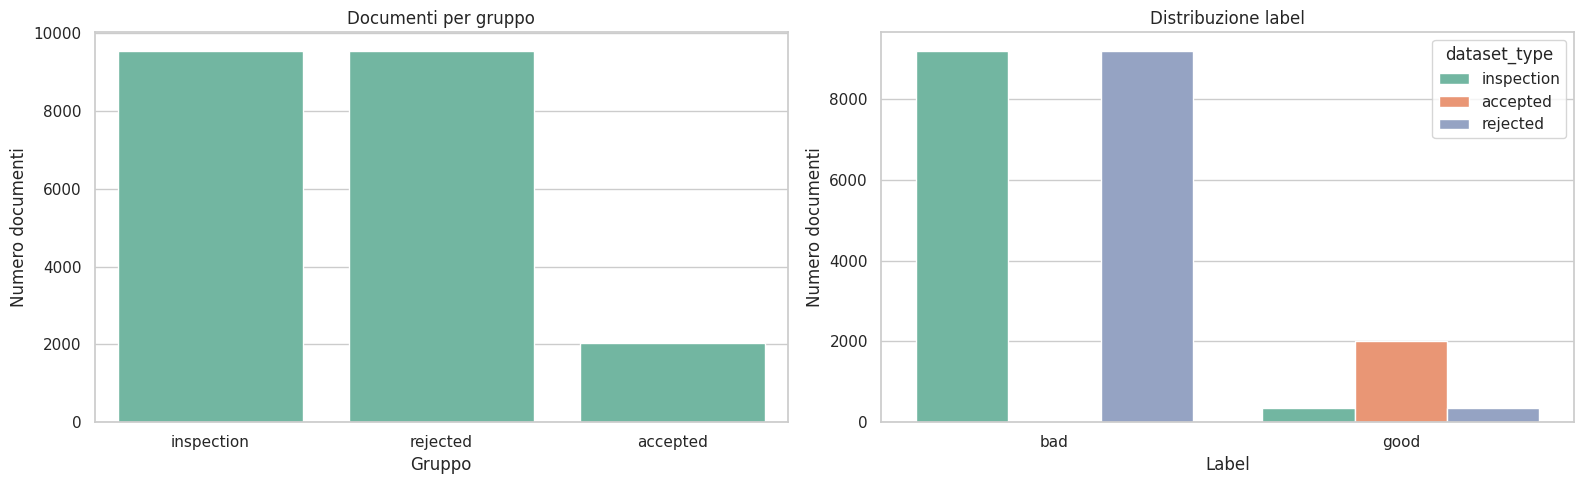

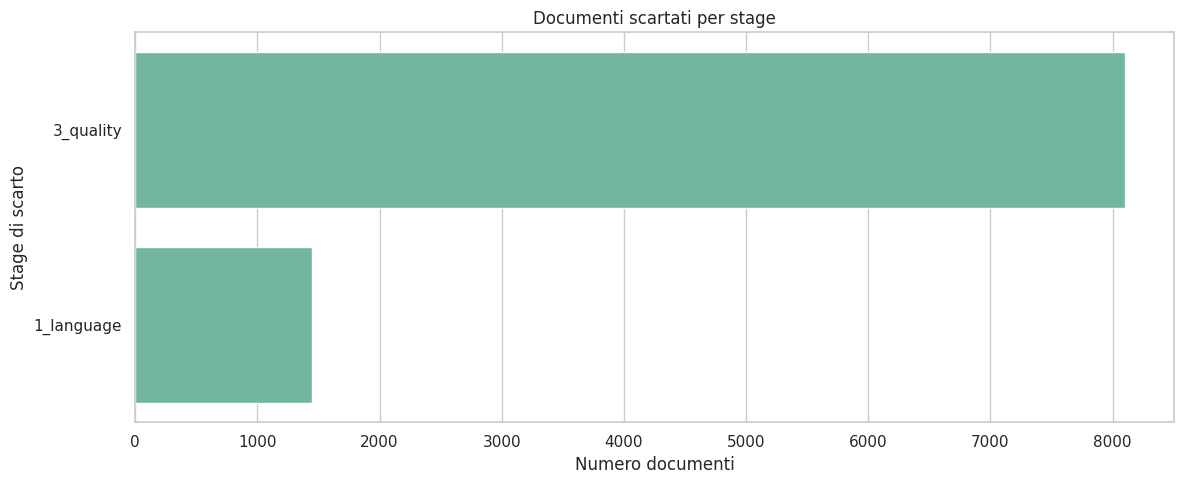

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x='dataset_type', order=df['dataset_type'].value_counts().index, ax=axes[0])
axes[0].set_title('Documenti per gruppo')
axes[0].set_xlabel('Gruppo')
axes[0].set_ylabel('Numero documenti')

label_df = df[df['label'].notna()].copy()
if not label_df.empty:
    sns.countplot(data=label_df, x='label', hue='dataset_type', ax=axes[1])
    axes[1].set_title('Distribuzione label')
    axes[1].set_xlabel('Label')
    axes[1].set_ylabel('Numero documenti')
else:
    axes[1].text(0.5, 0.5, 'Nessuna label trovata', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

rejected_df = df[df['dataset_type'] == 'rejected'].copy()
if not rejected_df.empty:
    plt.figure(figsize=(12, 5))
    order = rejected_df['rejection_stage'].value_counts().index
    sns.countplot(data=rejected_df, y='rejection_stage', order=order)
    plt.title('Documenti scartati per stage')
    plt.xlabel('Numero documenti')
    plt.ylabel('Stage di scarto')
    plt.tight_layout()
    plt.show()


Colonne numeriche disponibili per i grafici: ['text_length', 'word_count', 'language_score', 'quality_score', 'unique_word_ratio', 'stopword_ratio', 'spam_keyword_hits']


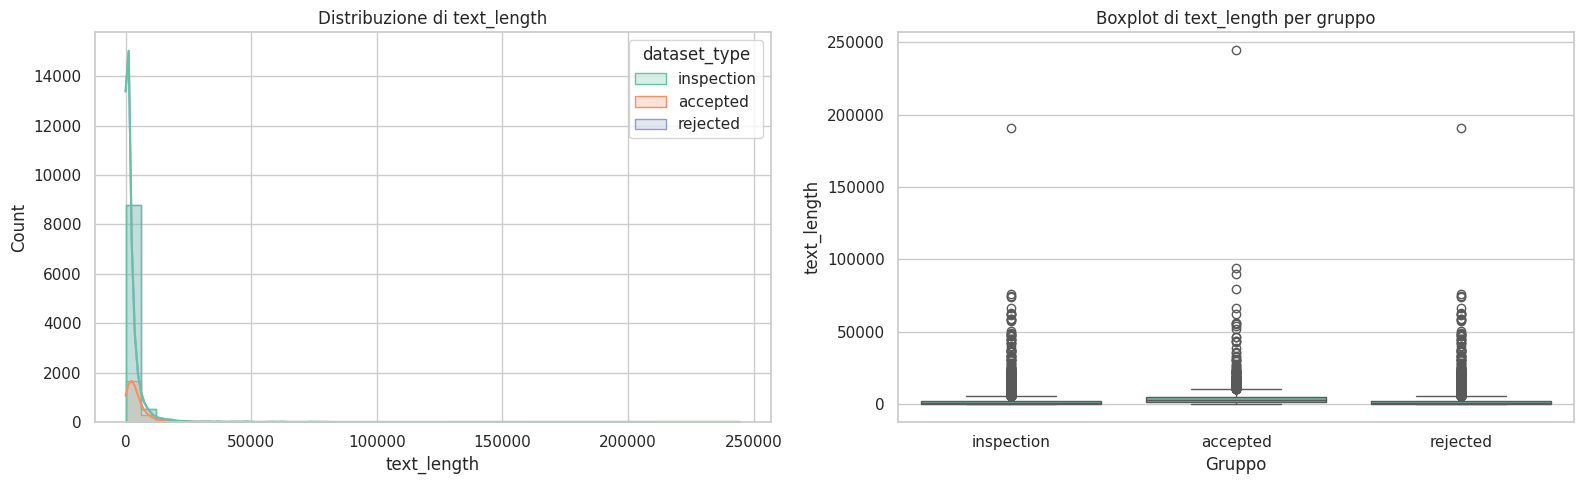

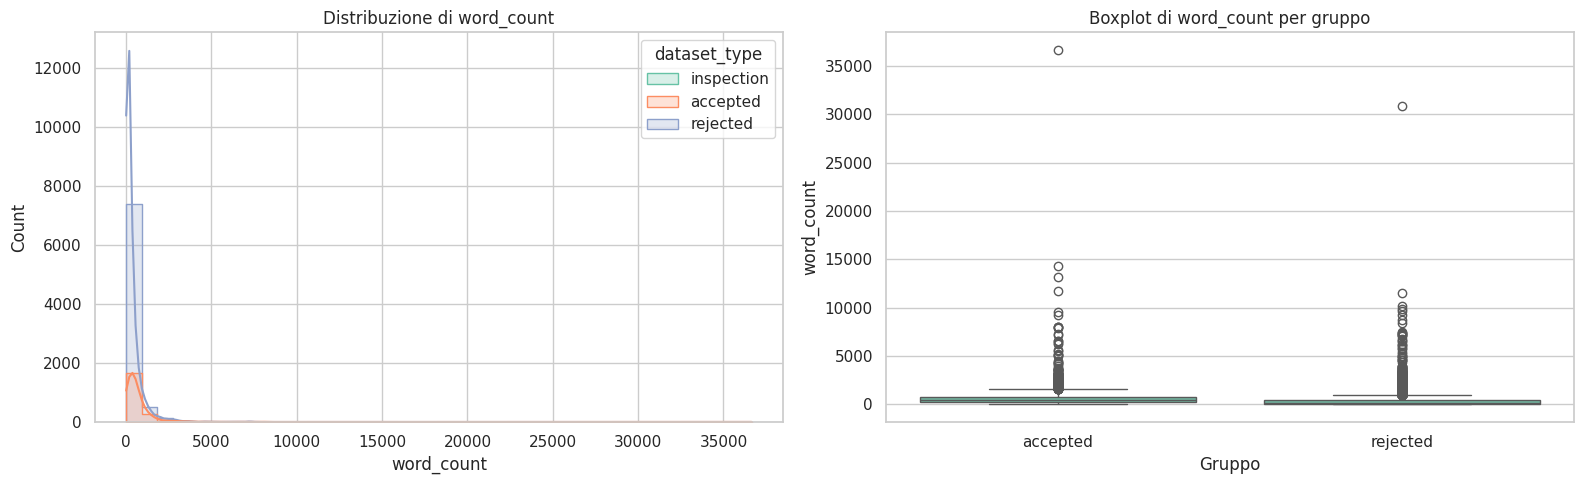

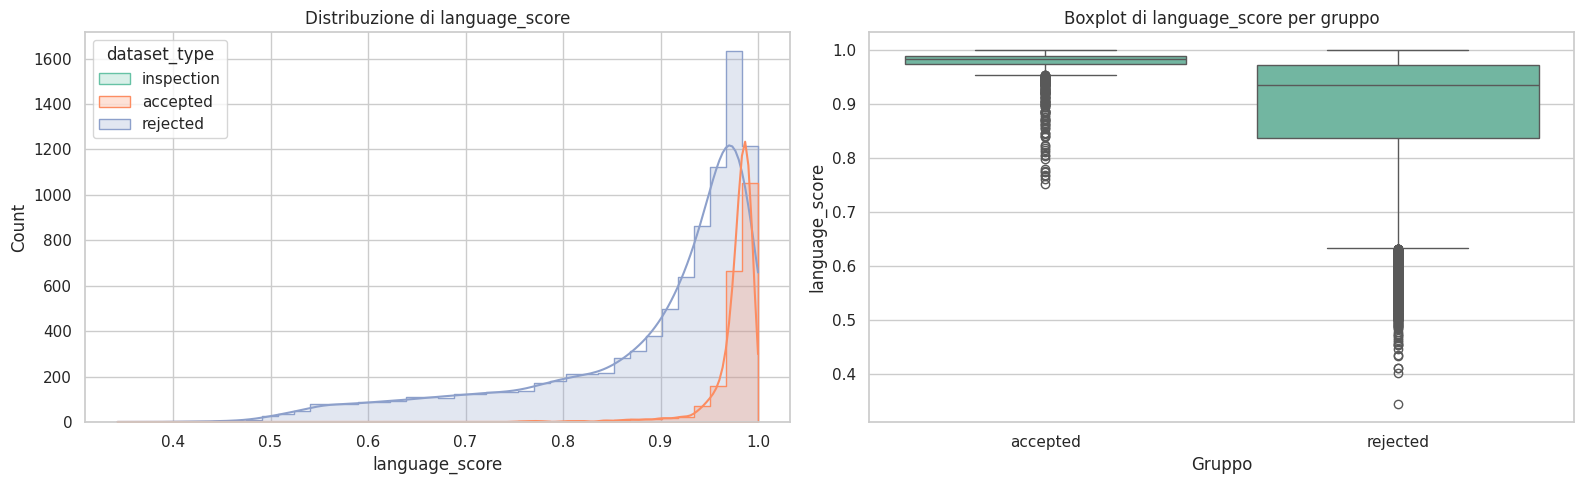

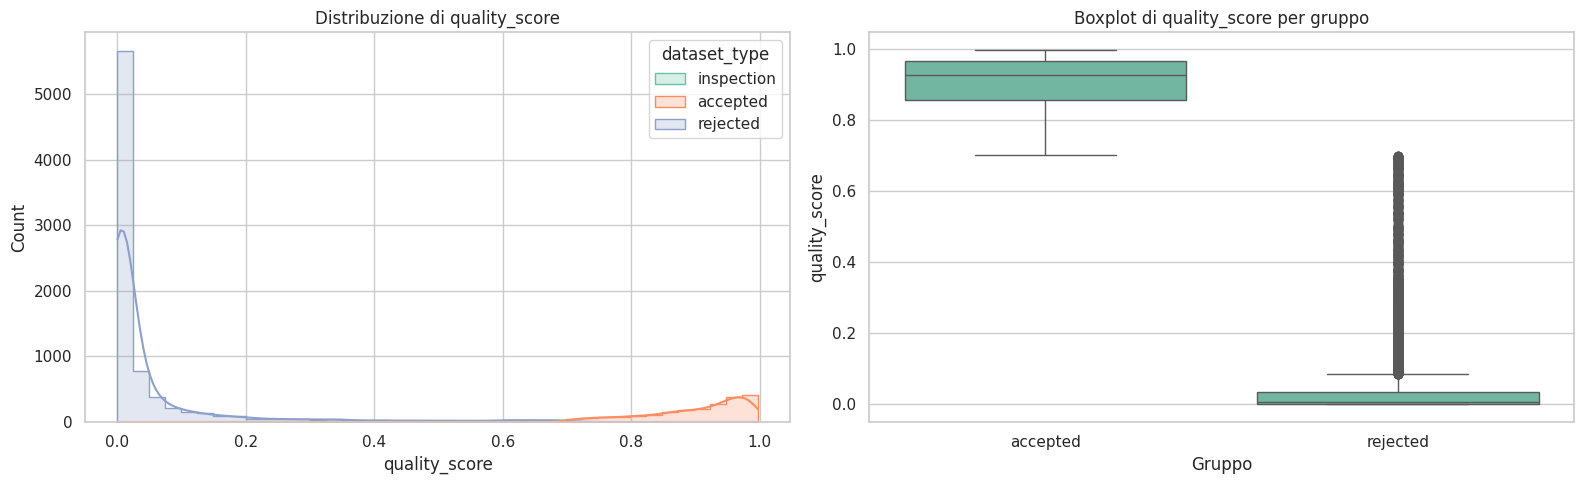

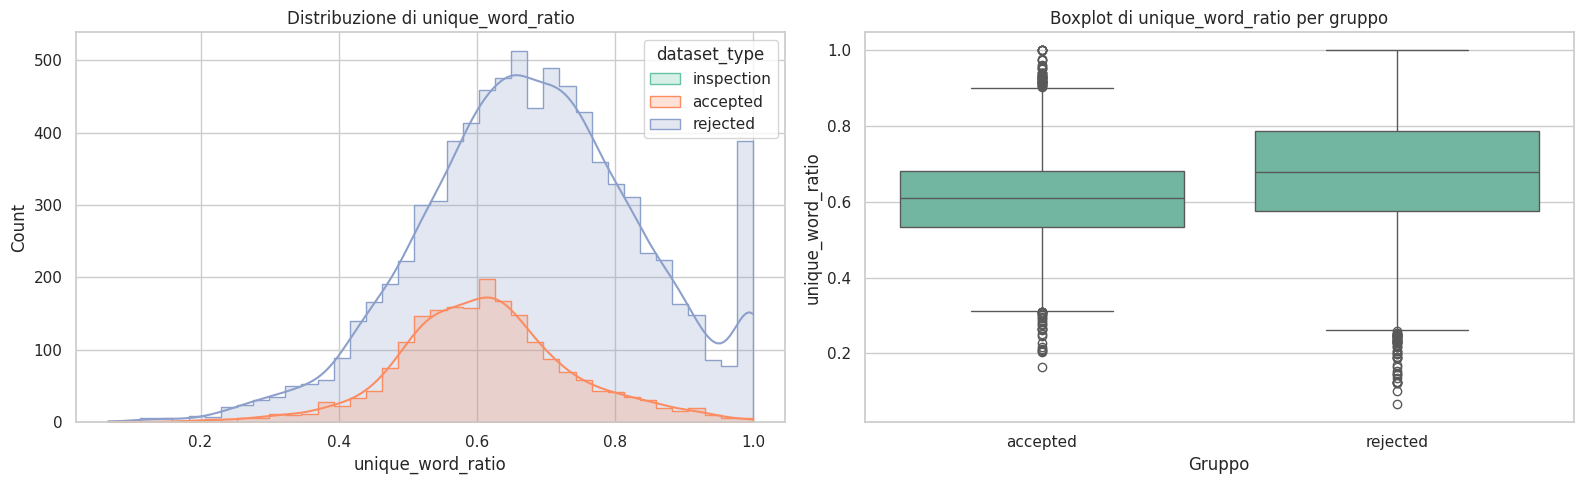

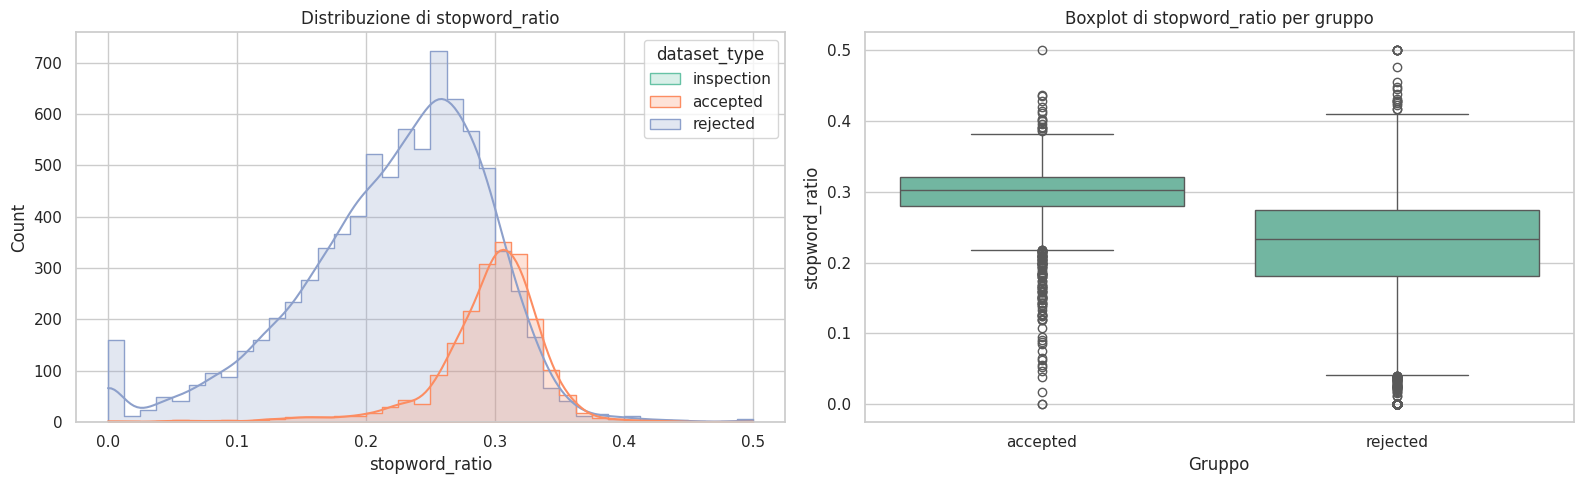

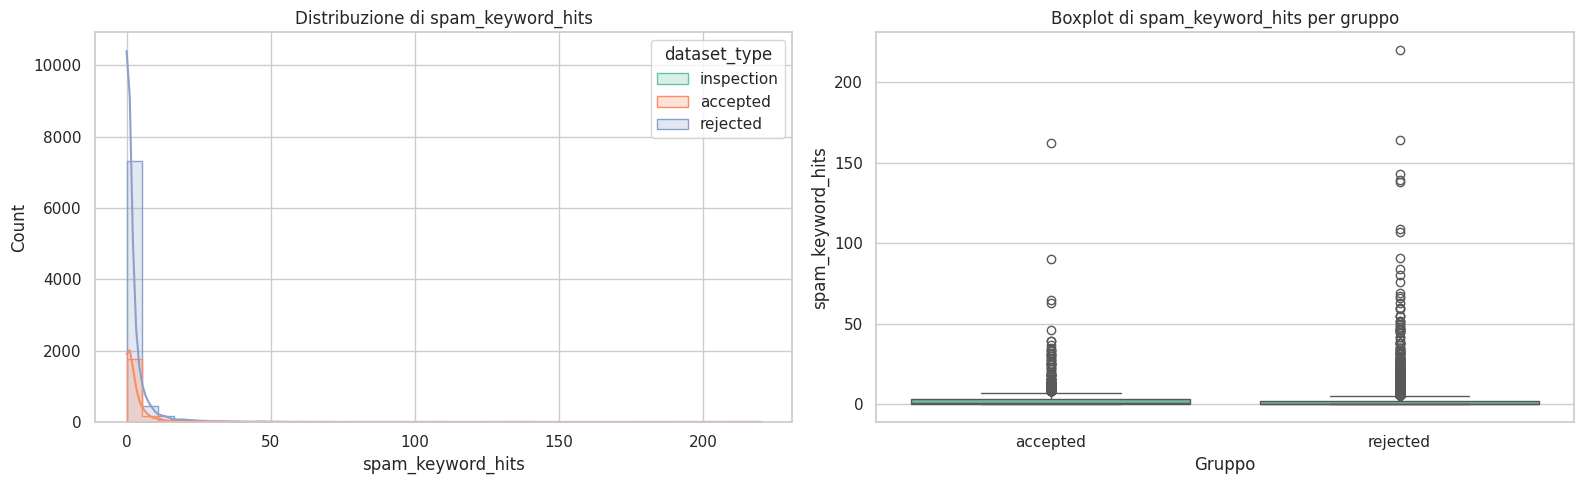

In [6]:
numeric_to_plot = [
    'text_length',
    'word_count',
    'language_score',
    'quality_score',
    'unique_word_ratio',
    'stopword_ratio',
    'spam_keyword_hits',
]

available = [c for c in numeric_to_plot if c in df.columns and df[c].notna().any()]
print('Colonne numeriche disponibili per i grafici:', available)

for col in available:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.histplot(data=df, x=col, hue='dataset_type', bins=40, kde=True, ax=axes[0], element='step')
    axes[0].set_title(f'Distribuzione di {col}')
    axes[0].set_xlabel(col)

    box_df = df[df[col].notna()].copy()
    if not box_df.empty:
        sns.boxplot(data=box_df, x='dataset_type', y=col, ax=axes[1])
        axes[1].set_title(f'Boxplot di {col} per gruppo')
        axes[1].set_xlabel('Gruppo')
        axes[1].set_ylabel(col)
    else:
        axes[1].text(0.5, 0.5, 'Dati non disponibili', ha='center', va='center')
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()


,quality_score,quality_label,label,dataset_type,source_file
9541,0.8768,good,good,accepted,italiano_pulito_00000.jsonl
9542,0.9158,good,good,accepted,italiano_pulito_00000.jsonl
9543,0.8015,good,good,accepted,italiano_pulito_00000.jsonl
9544,0.8946,good,good,accepted,italiano_pulito_00000.jsonl
9545,0.9560,good,good,accepted,italiano_pulito_00000.jsonl
9546,0.8662,good,good,accepted,italiano_pulito_00000.jsonl
9547,0.7925,good,good,accepted,italiano_pulito_00000.jsonl
9548,0.9540,good,good,accepted,italiano_pulito_00000.jsonl
9549,0.8784,good,good,accepted,italiano_pulito_00000.jsonl
9550,0.8687,good,good,accepted,italiano_pulito_00000.jsonl


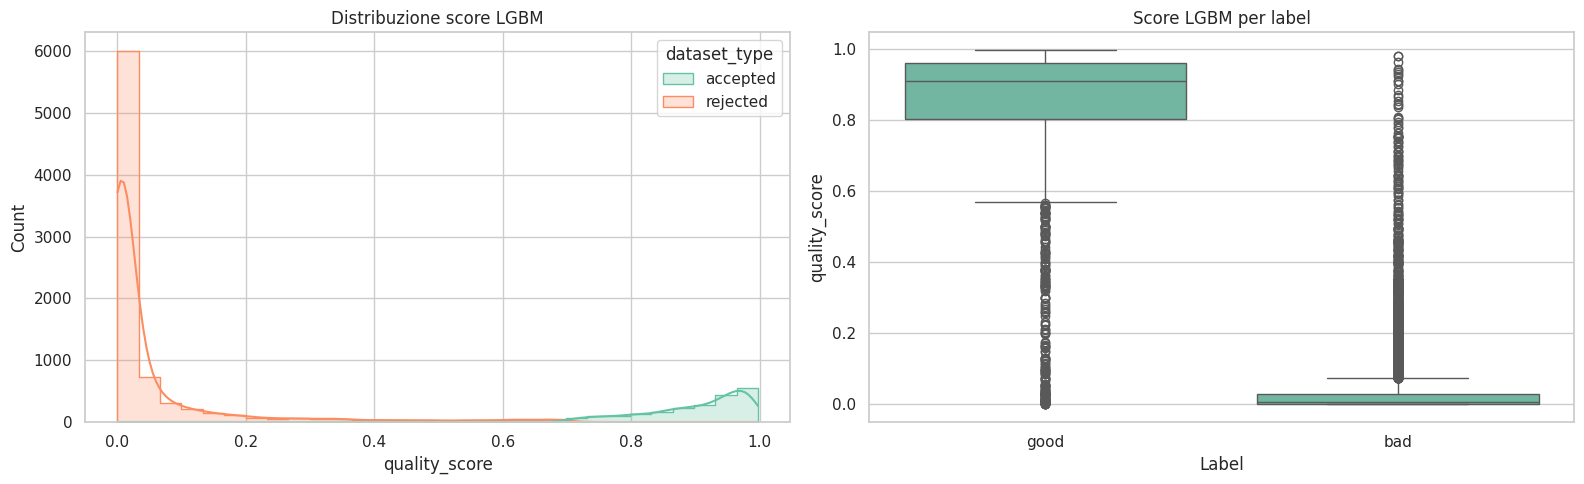

,score_bin,mean_score,positive_rate,count
0,"(-0.001, 0.1]",0.014621,0.010365,7043
1,"(0.1, 0.2]",0.143102,0.049676,463
2,"(0.2, 0.3]",0.248044,0.094737,190
3,"(0.3, 0.4]",0.345146,0.267717,127
4,"(0.4, 0.5]",0.449654,0.321839,87
5,"(0.5, 0.6]",0.552994,0.680556,72
6,"(0.6, 0.7]",0.651499,0.784483,116
7,"(0.7, 0.8]",0.755603,0.925651,269
8,"(0.8, 0.9]",0.856935,0.981096,529
9,"(0.9, 1.0]",0.955161,0.991150,1243


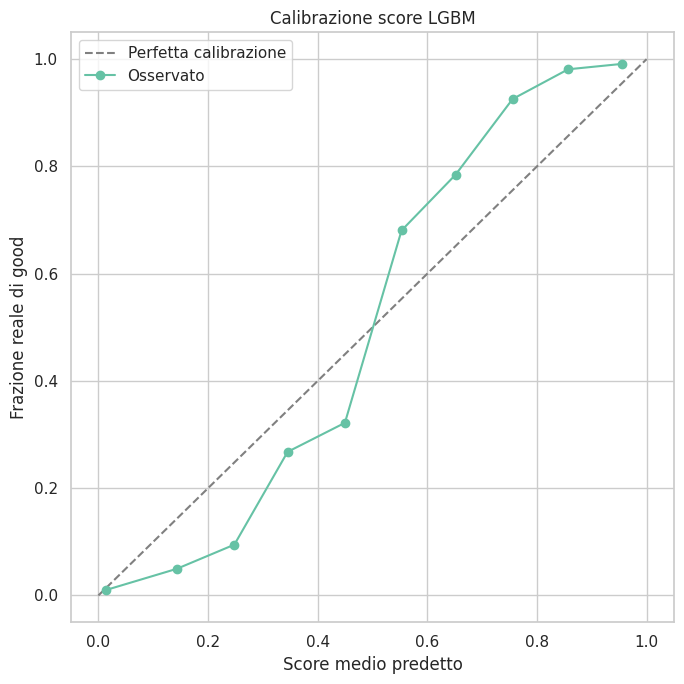

In [7]:
score_col_candidates = ['quality_score']
score_col = next((c for c in score_col_candidates if c in df.columns and df[c].notna().any()), None)

if score_col is None:
    print('Nessuno score LGBM trovato nei JSONL. Il notebook mostra comunque label e feature disponibili.')
else:
    lgbm_df = df[df[score_col].notna()].copy()
    display(lgbm_df[[score_col, 'quality_label', 'label', 'dataset_type', 'source_file']].head(10))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.histplot(data=lgbm_df, x=score_col, hue='dataset_type', bins=30, kde=True, ax=axes[0], element='step')
    axes[0].set_title('Distribuzione score LGBM')
    axes[0].set_xlabel(score_col)

    if lgbm_df['label'].notna().any():
        sns.boxplot(data=lgbm_df[lgbm_df['label'].notna()], x='label', y=score_col, ax=axes[1])
        axes[1].set_title('Score LGBM per label')
        axes[1].set_xlabel('Label')
        axes[1].set_ylabel(score_col)
    else:
        axes[1].text(0.5, 0.5, 'Label assenti per confronto score', ha='center', va='center')
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()

    if lgbm_df['label'].isin(['good', 'bad']).any():
        eval_df = lgbm_df[lgbm_df['label'].isin(['good', 'bad'])].copy()
        eval_df['label_bin'] = (eval_df['label'] == 'good').astype(int)
        eval_df['score_bin'] = pd.cut(eval_df[score_col], bins=np.linspace(0, 1, 11), include_lowest=True)
        calibration = eval_df.groupby('score_bin', observed=False).agg(
            mean_score=(score_col, 'mean'),
            positive_rate=('label_bin', 'mean'),
            count=('label_bin', 'size')
        ).reset_index()
        display(calibration)

        plt.figure(figsize=(7, 7))
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfetta calibrazione')
        plt.plot(calibration['mean_score'], calibration['positive_rate'], marker='o', label='Osservato')
        plt.title('Calibrazione score LGBM')
        plt.xlabel('Score medio predetto')
        plt.ylabel('Frazione reale di good')
        plt.legend()
        plt.tight_layout()
        plt.show()


,source_file,inspection_group,label,count
1,inspection/rejected_was_bad.jsonl,3_quality,bad,7782
0,inspection/rejected_was_bad.jsonl,1_language,bad,1410
3,inspection/rejected_was_good.jsonl,3_quality,good,316
2,inspection/rejected_was_good.jsonl,1_language,good,33


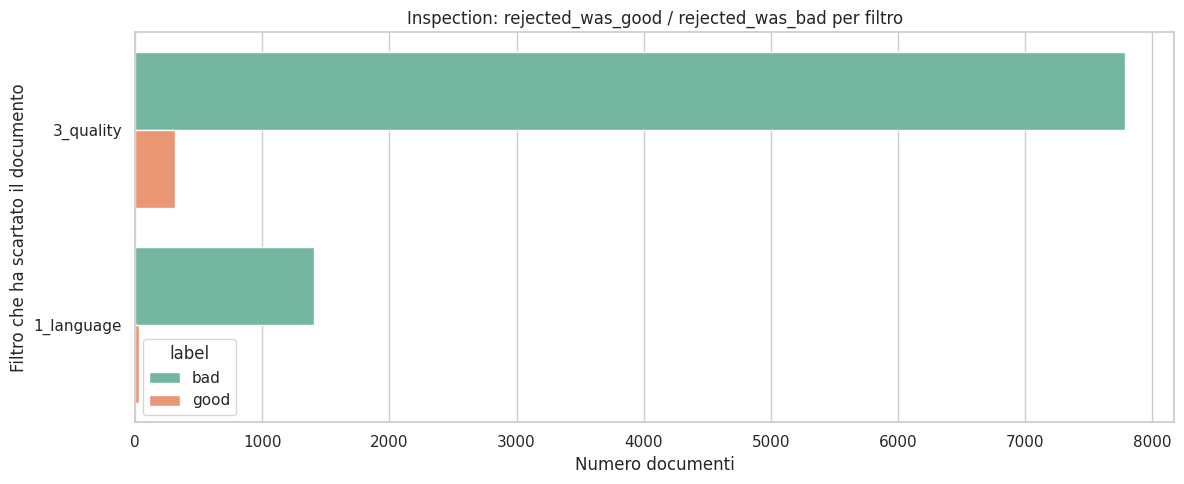

,source_file,inspection_group,label,text
0,inspection/rejected_was_bad.jsonl,3_quality,bad,"Emanuela\nPiedi nudi nella sabbia dei pioppeti, nelle stoppie, nei mucchi di granoturco, per sentirsi parte del mond..."
1,inspection/rejected_was_bad.jsonl,3_quality,bad,La calata G.B. Cuneo. Su un muro la lapide che ricorda il bombardamento della flotta di Luigi XIV.\nLa casa di sinis...
2,inspection/rejected_was_bad.jsonl,3_quality,bad,Vieni all’evento del 18 maggio “Windows Phone 7 Day” a Bari organizzato da DotNetSide con la collaborazione di Micro...
3,inspection/rejected_was_bad.jsonl,3_quality,bad,"Meglio!Si potrei rimpicciolirle\nUn consiglio: le immagini chi sono, forum è possibile farle un po' più piccole?\nPe..."
4,inspection/rejected_was_bad.jsonl,3_quality,bad,- Fai shopping e guadagna con il cashback [chiudi]\nSapphire 11190-09-20G 6450-2g-d3\n- tu paghi al negozio\n- €0\n-...
5,inspection/rejected_was_bad.jsonl,3_quality,bad,"[imc-abruzzo] Aggiornata ftr ""regione e legge 30""\nalfred\nsp1een a riseup.net\nMer 23 Nov 2005 15:58:37 PST\nho ins..."
6,inspection/rejected_was_bad.jsonl,3_quality,bad,Corsi di Musica\n- Bachelor of Art\n- Come scrivere una canzone\n- Concerti Allievi\n- Coro Gospel\n- Corsi Certific...
7,inspection/rejected_was_bad.jsonl,3_quality,bad,Firefox 3.5Un veloce tour per passare in rassegna le maggiori novità introdotte da Mozilla nella nuova versione 3.5 ...
8,inspection/rejected_was_bad.jsonl,3_quality,bad,"Kursaal , Merano\nPrevendita biglietti presso tutte le librerie Athesia, Baba's (Bolzano), Non Stop Music (Merano) e..."
9,inspection/rejected_was_bad.jsonl,3_quality,bad,"Ciao, è la tua prima visita? sai che su CoPlaNet.it c'è una ricca comunità pronta ad aiutarti? Sai che è il sito di ..."


In [8]:
inspection_df = df[df['dataset_type'] == 'inspection'].copy()
if inspection_df.empty:
    print('Nessun file inspection trovato.')
else:
    display(
        inspection_df.groupby(['source_file', 'inspection_group', 'label'], dropna=False)
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )

    plt.figure(figsize=(12, 5))
    sns.countplot(data=inspection_df, y='inspection_group', hue='label')
    plt.title('Inspection: rejected_was_good / rejected_was_bad per filtro')
    plt.xlabel('Numero documenti')
    plt.ylabel('Filtro che ha scartato il documento')
    plt.tight_layout()
    plt.show()

inspection_df[['source_file', 'inspection_group', 'label', 'text']].head(10)


In [9]:
MANUAL_INPUT_DIR = None
# Esempio:
# MANUAL_INPUT_DIR = '/content/drive/MyDrive/ita-llm-pipeline/data/train'


def looks_like_input_dir(path: Path) -> bool:
    return path.exists() and path.is_dir() and any(path.rglob('*.jsonl'))


def find_input_dir() -> Path:
    if MANUAL_INPUT_DIR:
        manual = Path(MANUAL_INPUT_DIR)
        if looks_like_input_dir(manual):
            return manual
        raise FileNotFoundError(f'Il path input manuale non contiene JSONL validi: {manual}')

    cwd = Path.cwd()
    candidates = [
        cwd / 'data' / 'train',
        # cwd / 'data',
        cwd.parent / 'data' / 'train',
        # cwd.parent / 'data',
        OUTPUT_DIR.parent / 'data' / 'train',
        # OUTPUT_DIR.parent / 'data',
    ]

    for candidate in candidates:
        if looks_like_input_dir(candidate):
            return candidate

    raise FileNotFoundError(
        'Non trovo la cartella input. Imposta MANUAL_INPUT_DIR con il path corretto.'
    )


def load_input_jsonl(input_dir: Path) -> pd.DataFrame:
    rows = []
    start_error_count = len(JSONL_READ_ERRORS)
    for path in sorted(input_dir.rglob('*.jsonl')):
        for obj in open_jsonl(path):
            metadata = obj.get('metadata', {}) or {}
            rows.append({
                'input_source_file': str(path.relative_to(input_dir)),
                'id': str(obj.get('id') or metadata.get('doc_id') or ''),
                'text': obj.get('text'),
                'input_label': obj.get('label') or metadata.get('label') or metadata.get('tag'),
                'input_language': metadata.get('language') or obj.get('language'),
                'input_language_score': metadata.get('language_score') or obj.get('language_score'),
            })
    input_df = pd.DataFrame(rows)
    input_df['id'] = input_df['id'].astype(str)
    input_df['input_label'] = input_df['input_label'].replace({'keep': 'good', 'reject': 'bad'})
    new_errors = pd.DataFrame(JSONL_READ_ERRORS[start_error_count:])
    if not new_errors.empty:
        print(f'Righe input saltate per JSON malformato: {len(new_errors)}')
        display(new_errors[['file', 'line_number', 'error']].head(20))
    return input_df


INPUT_DIR = find_input_dir()
input_df = load_input_jsonl(INPUT_DIR)
print(f'Input directory trovata: {INPUT_DIR}')
print(f'Righe input caricate: {len(input_df):,}')
display(input_df.head(5))


[WARN] Riga JSON malformata saltata: /home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl (linea 251)
[WARN] Riga JSON malformata saltata: /home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl (linea 260)
[WARN] Riga JSON malformata saltata: /home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl (linea 269)
[WARN] Riga JSON malformata saltata: /home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl (linea 286)
[WARN] Riga JSON malformata saltata: /home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl (linea 291)
Righe input saltate per JSON malformato: 5


,file,line_number,error
0,/home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl,251,"Expecting ',' delimiter: line 1 column 10792 (char 10791)"
1,/home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl,260,Extra data: line 1 column 23567 (char 23566)
2,/home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl,269,Extra data: line 1 column 1166 (char 1165)
3,/home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl,286,Extra data: line 1 column 2179 (char 2178)
4,/home/stefano/ita-llm-pipeline/data/train/hand_label.jsonl,291,Extra data: line 1 column 1484 (char 1483)


Input directory trovata: /home/stefano/ita-llm-pipeline/data/train
Righe input caricate: 11,582


,input_source_file,id,text,input_label,input_language,input_language_score
0,hand_label.jsonl,<urn:uuid:e03bf59e-38e1-49e4-b2d0-1e2e5c691c26>,"Emanuela\nPiedi nudi nella sabbia dei pioppeti, nelle stoppie, nei mucchi di granoturco, per sentirsi parte del mond...",bad,ita,0.997187
1,hand_label.jsonl,<urn:uuid:dad189e9-6a8b-459d-ba14-935c2822692c>,Situazione: Situato in una posizione strategica nel cuore verde della Romagna questo hotel sorge non lontano da nume...,good,ita,0.989889
2,hand_label.jsonl,<urn:uuid:f10832a3-4e1b-4474-88a6-a040f893280c>,"Le gelide giornate invernali non hanno tolto brio al giovane ed euforico gruppo dei “Beli Nui”, nuovamente pronto a ...",good,ita,0.990867
3,hand_label.jsonl,<urn:uuid:942da32e-e413-457d-ba63-67ad1d03a1f9>,"Bruschetta con pomodori e melanzane è un antipasto,diverso dal solito.Avevo delle melanzane fritte da far fuori ..un...",good,ita,0.938583
4,hand_label.jsonl,<urn:uuid:5bb296b4-7f09-4d99-be0c-20080217d121>,Tutte le partite della lega di sviluppo del basket americano (NBA Development League) si possono vedere in diretta s...,good,ita,0.996456


,total_input_docs,total_evaluable_docs,matched_output_docs,missing_output_docs,label_errors,label_error_rate,false_reject,false_accept
0,11582,11582,496,11086,66,0.005698,56,10


pipeline_prediction,bad,good,missing
input_label,,,
bad,248,10,8975
good,56,182,2111


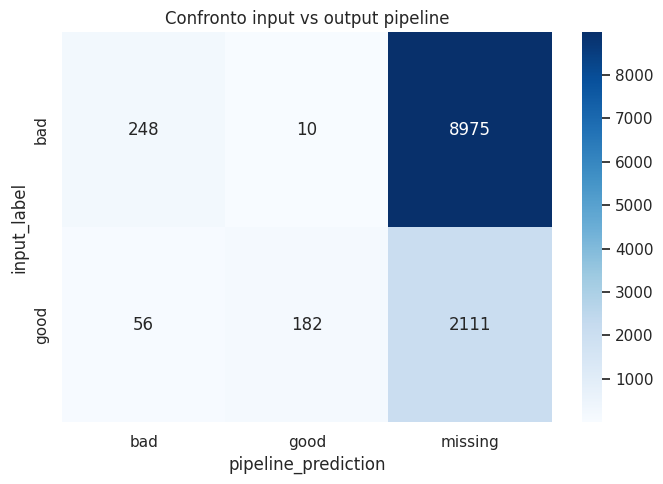

,id,input_label,predicted_label_from_pipeline,error_type,pipeline_decision,rejection_stage,input_source_file,source_file,text
3,<urn:uuid:942da32e-e413-457d-ba63-67ad1d03a1f9>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,"Bruschetta con pomodori e melanzane è un antipasto,diverso dal solito.Avevo delle melanzane fritte da far fuori ..un..."
6,<urn:uuid:0b06038d-553a-4731-b131-fec59b88b4cc>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,"Per iniziare, puoi seguire i tuoi amici di Facebook o Twitter che sono già membri di Chicisimo.\nPerché devo diventa..."
10,<urn:uuid:ba407bb8-8b65-408e-9b8b-86454677408a>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,Grazie capo! Non vedo l'ora di vedere i nuovi Mario Kart e Smash Bros per riaprirti le chiappette!\nGatsu mi serve a...
31,<urn:uuid:ff5c50c1-7f17-4bd5-87a6-8f1db65e1f33>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,Free Online Dictionary\nvena cava superiore\n|Wikipedia Italiano L'enciclopedia libera||Download this dictionary|\nV...
33,<urn:uuid:7d5dbe23-faf5-4f50-8ca0-305c1352ff1f>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,"Ricetta dei muffin integrali ovvero l’impasto base\nEcco la ricetta dei muffin integrali senza alcuna aggiunta, nè d..."
34,<urn:uuid:fc32b4b0-baa5-495d-b907-99c3906c0f1b>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,"\n\nPunto di riferimento per chi ama la moda di tendenza come per chi preferisce lo stile della tradizione, CARRARO ..."
41,<urn:uuid:d3bf44a2-e51b-4038-9e95-6a5ba7d5f179>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,La lavorazione di Breaking Dawn è giunta alle battute finali. Robert Pattinson e Kristen Stewart sono atterrati a Va...
44,<urn:uuid:470817c7-dd1e-4524-803e-09a2593817f6>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,I resti dell'antica cattedrale di Firenze sono ancor oggi visitabili sotto il Duomo di Santa Maria del Fiore.\nIl no...
46,<urn:uuid:f7a0a9af-9e0c-4ea0-82d3-c44bdcd330fb>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,"Il blog “InTime, condivido per comunicare” è un sito che si occupa di social media e web marketing, ma anche di cons..."
47,<urn:uuid:9899d103-e05d-4e64-a9e0-19894fd8ba3f>,good,bad,false_reject,rejected,3_quality,hand_label.jsonl,rejected/3_quality/quality_rejectd_00000.jsonl,Non troverai lo stesso appartamento ad un prezzo più basso. Te lo garantiamo.\nCon una selezione così ampia di appar...


In [10]:
output_eval = df[df['dataset_type'] != 'inspection'].copy()
output_eval['id'] = output_eval['id'].astype(str)
output_eval['pipeline_decision'] = np.where(output_eval['dataset_type'] == 'accepted', 'kept', 'rejected')
output_eval['predicted_label_from_pipeline'] = np.where(output_eval['pipeline_decision'] == 'kept', 'good', 'bad')

priority = {'rejected': 0, 'accepted': 1}
output_eval['decision_priority'] = output_eval['dataset_type'].map(priority).fillna(99)
output_eval = output_eval.sort_values(['id', 'decision_priority', 'source_file'])
output_eval = output_eval.drop_duplicates(subset=['id'], keep='first')

comparison_df = input_df.merge(
    output_eval[
        ['id', 'dataset_type', 'source_file', 'rejection_stage', 'pipeline_decision', 'predicted_label_from_pipeline', 'quality_score', 'quality_label']
    ],
    on='id',
    how='left'
)

comparison_df['found_in_output'] = comparison_df['pipeline_decision'].notna()
comparison_df['pipeline_decision'] = comparison_df['pipeline_decision'].fillna('missing')
comparison_df['predicted_label_from_pipeline'] = comparison_df['predicted_label_from_pipeline'].fillna('missing')
comparison_df['is_label_error'] = (
    comparison_df['input_label'].isin(['good', 'bad'])
    & comparison_df['predicted_label_from_pipeline'].isin(['good', 'bad'])
    & (comparison_df['input_label'] != comparison_df['predicted_label_from_pipeline'])
)

comparison_df['error_type'] = np.select(
    [
        comparison_df['input_label'].eq('good') & comparison_df['predicted_label_from_pipeline'].eq('bad'),
        comparison_df['input_label'].eq('bad') & comparison_df['predicted_label_from_pipeline'].eq('good'),
        comparison_df['predicted_label_from_pipeline'].eq('missing'),
    ],
    [
        'false_reject',
        'false_accept',
        'missing_in_output',
    ],
    default='correct'
)

evaluation_df = comparison_df[comparison_df['input_label'].isin(['good', 'bad'])].copy()
total_evaluable = len(evaluation_df)
total_errors = int(evaluation_df['is_label_error'].sum())
error_rate = (total_errors / total_evaluable) if total_evaluable else np.nan

summary_eval = pd.DataFrame([
    {
        'total_input_docs': int(len(input_df)),
        'total_evaluable_docs': int(total_evaluable),
        'matched_output_docs': int(comparison_df['found_in_output'].sum()),
        'missing_output_docs': int((~comparison_df['found_in_output']).sum()),
        'label_errors': total_errors,
        'label_error_rate': error_rate,
        'false_reject': int((evaluation_df['error_type'] == 'false_reject').sum()),
        'false_accept': int((evaluation_df['error_type'] == 'false_accept').sum()),
    }
])

display(summary_eval)

confusion = pd.crosstab(
    evaluation_df['input_label'],
    evaluation_df['predicted_label_from_pipeline'],
    rownames=['input_label'],
    colnames=['pipeline_prediction'],
    dropna=False
)
display(confusion)

plt.figure(figsize=(7, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Confronto input vs output pipeline')
plt.tight_layout()
plt.show()

error_examples = evaluation_df[evaluation_df['is_label_error']].copy()
display(
    error_examples[
        ['id', 'input_label', 'predicted_label_from_pipeline', 'error_type', 'pipeline_decision', 'rejection_stage', 'input_source_file', 'source_file', 'text']
    ].head(20)
)


In [44]:
# RUN_NAME = pd.Timestamp.now().strftime('run_%Y%m%d_%H%M%S')
# REPORTS_BASE_DIR = OUTPUT_DIR / 'analysis'
# REPORT_DIR = REPORTS_BASE_DIR / RUN_NAME
# REPORT_DIR.mkdir(parents=True, exist_ok=True)

# comparison_df.to_csv(REPORT_DIR / 'comparison_full.csv', index=False)
# evaluation_df.to_csv(REPORT_DIR / 'comparison_evaluable_only.csv', index=False)
# error_examples.to_csv(REPORT_DIR / 'misclassified_examples.csv', index=False)
# summary_eval.to_csv(REPORT_DIR / 'summary_metrics.csv', index=False)
# confusion.to_csv(REPORT_DIR / 'confusion_matrix.csv')
# pd.DataFrame({
#     'error_type': evaluation_df['error_type'].value_counts(dropna=False).index,
#     'count': evaluation_df['error_type'].value_counts(dropna=False).values,
# }).to_csv(REPORT_DIR / 'error_breakdown.csv', index=False)

# run_metadata = {
#     'run_name': RUN_NAME,
#     'input_dir': str(INPUT_DIR),
#     'output_dir': str(OUTPUT_DIR),
#     'report_dir': str(REPORT_DIR),
#     'total_input_docs': int(len(input_df)),
#     'total_evaluable_docs': int(total_evaluable),
#     'matched_output_docs': int(comparison_df['found_in_output'].sum()),
#     'label_errors': int(total_errors),
#     'label_error_rate': None if pd.isna(error_rate) else float(error_rate),
# }

# with open(REPORT_DIR / 'run_metadata.json', 'w', encoding='utf-8') as f:
#     json.dump(run_metadata, f, ensure_ascii=False, indent=2)

# print(f'Report salvati in: {REPORT_DIR}')
# sorted(p.name for p in REPORT_DIR.iterdir())
